<a href="https://colab.research.google.com/github/Kamala-Juvvala/Predictive_Analytics/blob/Customer_movement_optimization/Customer_movement_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

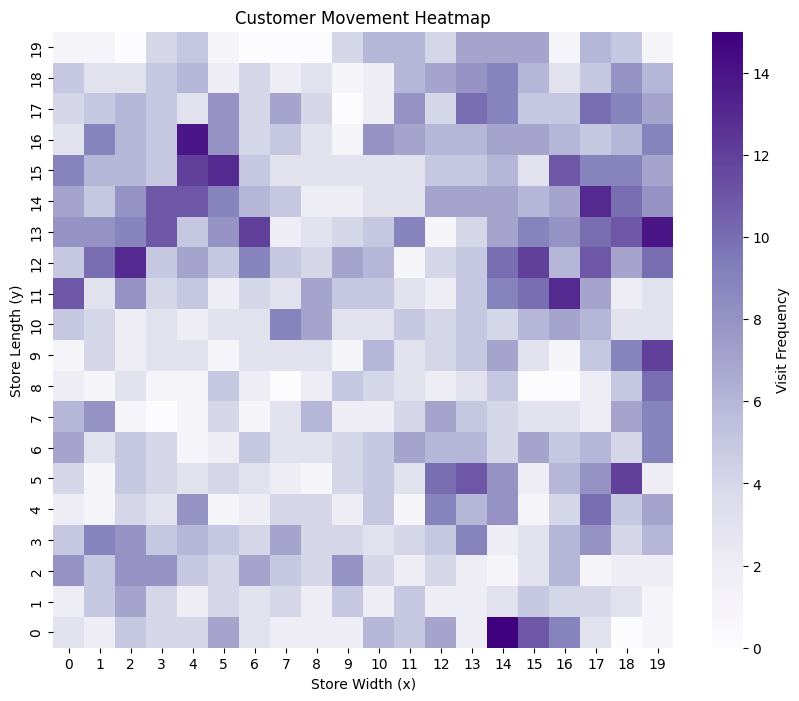

📍 Suggested High-Traffic Zones for Product Placement:
      x   y  count
14    0  14     15
324  16   4     14
279  13  19     14
297  14  17     13
305  15   5     13


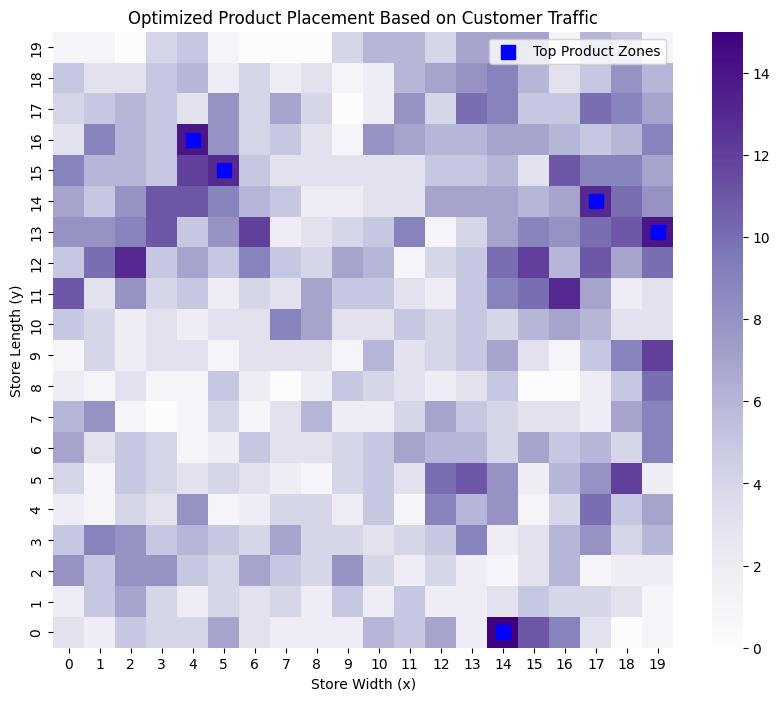

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate random customer paths in a 20x20 store grid
np.random.seed(42)
num_customers = 100
store_size = 20
movement_data = []

for customer_id in range(num_customers):
    path_length = np.random.randint(10, 30)
    x, y = np.random.randint(0, store_size, size=2)
    for _ in range(path_length):
        dx, dy = np.random.choice([-1, 0, 1]), np.random.choice([-1, 0, 1])
        x, y = max(0, min(store_size - 1, x + dx)), max(0, min(store_size - 1, y + dy))
        movement_data.append([customer_id, x, y])

df = pd.DataFrame(movement_data, columns=['customer_id', 'x', 'y'])
# Count how many times each (x, y) is visited
heatmap_data = df.groupby(['x', 'y']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='Purples', cbar_kws={'label': 'Visit Frequency'})
plt.title("Customer Movement Heatmap")
plt.xlabel("Store Width (x)")
plt.ylabel("Store Length (y)")
plt.gca().invert_yaxis()
plt.show()
# Flatten the heatmap and find top N visited areas
visit_counts = heatmap_data.stack().reset_index()
visit_counts.columns = ['x', 'y', 'count']
top_zones = visit_counts.sort_values(by='count', ascending=False).head(5)

print("📍 Suggested High-Traffic Zones for Product Placement:")
print(top_zones)
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='Purples')
plt.scatter(top_zones['y'] + 0.5, top_zones['x'] + 0.5, c='blue', marker='s', s=100, label='Top Product Zones')
plt.legend()
plt.title("Optimized Product Placement Based on Customer Traffic")
plt.xlabel("Store Width (x)")
plt.ylabel("Store Length (y)")
plt.gca().invert_yaxis()
plt.show()

